
슈퍼 리뷰어 vs 일반 리뷰어 프로필 요약


author_num_games_owned        author_playtime_at_review         \
                                mean median                      mean median   
reviewer_type                                                                  
General                       314.10   52.0                   1389.09  321.0   
Super                         347.23  100.0                   1684.34  421.5   

              author_num_reviews         
                            mean median  
reviewer_type                            
General                    54.38   14.0  
Super                      43.19   13.0

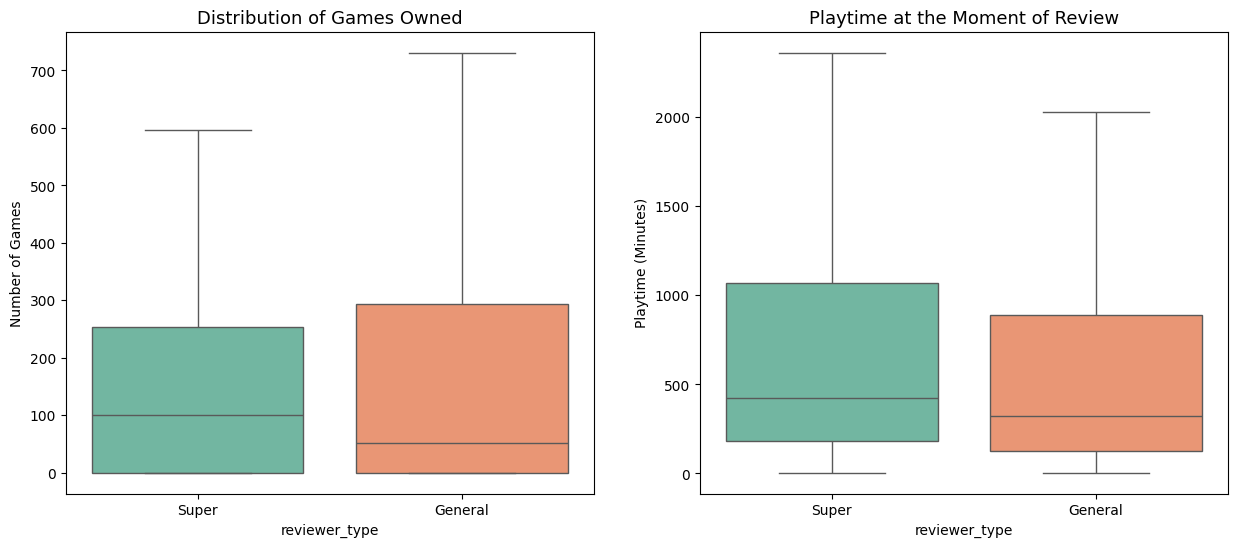

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 74개 정예 필터링 (일관성 유지)
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 74개 정예 게임 추출 (stratum 활용)
target_strata = ['large_high', 'mid_high', 'small_high']
df_high_apps = df_sample[df_sample['stratum'].isin(target_strata)]['appid'].unique()
df_target_reviews = df_reviews[df_reviews['appid'].isin(df_high_apps)].copy()

# 2. 슈퍼 리뷰어 정의 (상위 5% weighted_vote_score)
# 0점인 경우는 제외하고 계산 (의미 있는 투표를 받은 리뷰만 대상)
valid_reviews = df_target_reviews[df_target_reviews['weighted_vote_score'] > 0]
threshold = valid_reviews['weighted_vote_score'].quantile(0.95)

df_target_reviews['reviewer_type'] = np.where(
    df_target_reviews['weighted_vote_score'] >= threshold, 'Super', 'General'
)

# 3. 그룹별 프로필 비교 분석
# 분석 항목: 보유 게임 수, 리뷰 시점 플레이 시간, 총 리뷰 수
profile_features = {
    'author_num_games_owned': 'Games Owned',
    'author_playtime_at_review': 'Playtime at Review',
    'author_num_reviews': 'Total Reviews Written'
}

report = df_target_reviews.groupby('reviewer_type')[list(profile_features.keys())].agg(['mean', 'median']).round(2)

# 4. 시각화: 슈퍼 리뷰어 vs 일반 리뷰어 프로필 차이
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (1) 보유 게임 수 비교 (수정 버전)
sns.boxplot(data=df_target_reviews, x='reviewer_type', y='author_num_games_owned', 
            hue='reviewer_type', legend=False,  # hue와 legend 추가
            ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Distribution of Games Owned', fontsize=13)
axes[0].set_ylabel('Number of Games')

# (2) 리뷰 작성 시점 플레이 시간 비교 (수정 버전)
sns.boxplot(data=df_target_reviews, x='reviewer_type', y='author_playtime_at_review', 
            hue='reviewer_type', legend=False,  # hue와 legend 추가
            ax=axes[1], palette='Set2', showfliers=False)
axes[1].set_title('Playtime at the Moment of Review', fontsize=13)
axes[1].set_ylabel('Playtime (Minutes)')

print("\n" + "="*60)
print("슈퍼 리뷰어 vs 일반 리뷰어 프로필 요약")
print("="*60)
display(report)
print("="*60)

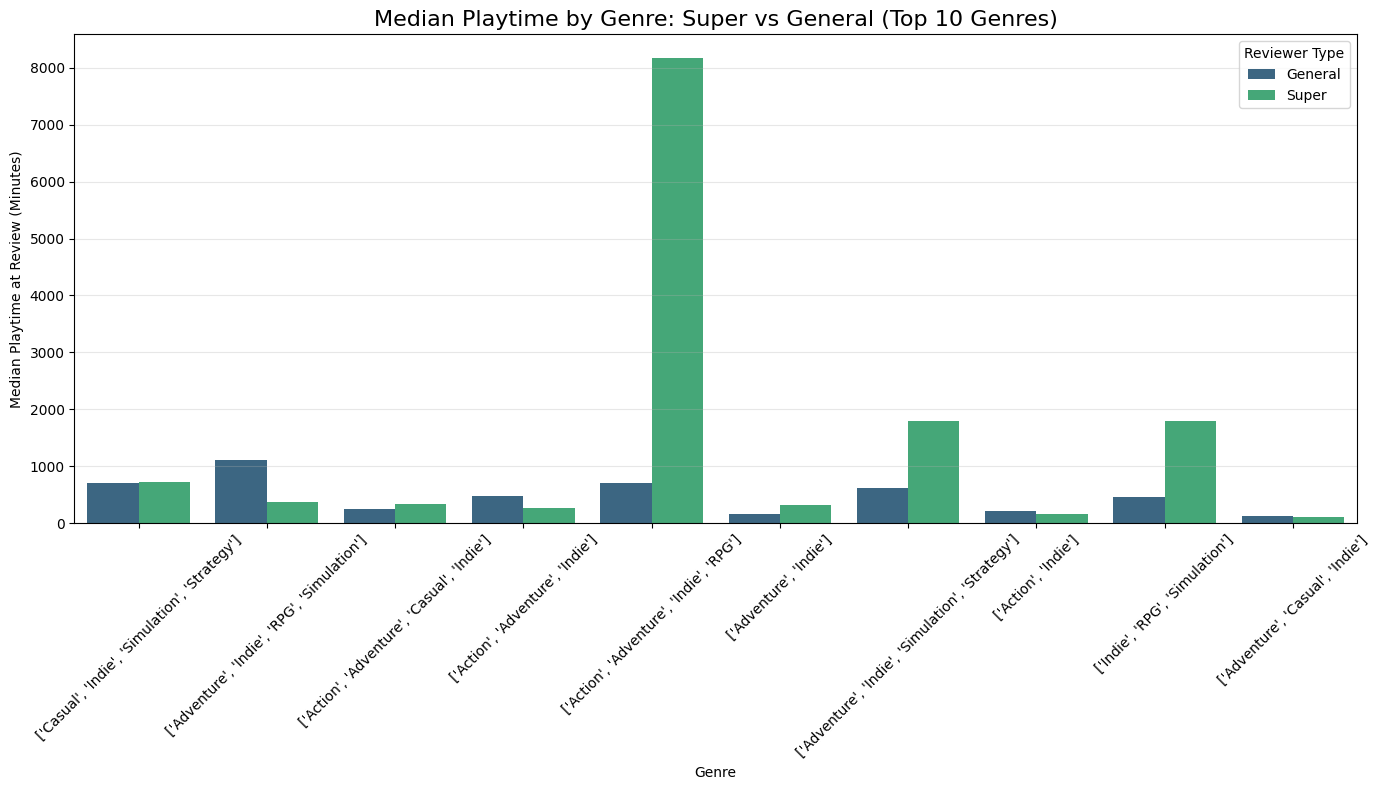


 📊 장르별 슈퍼 리뷰어 프로필 (중앙값 기준)


author_num_games_owned  \
reviewer_type                                                   General   
genre_list                                                                
['Action', 'Adventure', 'Casual', 'Indie']                        137.0   
['Action', 'Adventure', 'Indie', 'RPG']                            94.0   
['Action', 'Adventure', 'Indie']                                   44.0   
['Action', 'Indie']                                                78.0   
['Adventure', 'Casual', 'Indie']                                   49.0   
['Adventure', 'Indie', 'RPG', 'Simulation']                        38.0   
['Adventure', 'Indie', 'Simulation', 'Strategy']                    0.0   
['Adventure', 'Indie']                                             52.0   
['Casual', 'Indie', 'Simulation', 'Strategy']                      89.0   
['Indie', 'RPG', 'Simulation']                                      0.0   

                                                         \
reviewer_type                                     Super   
genre_list                                                
['Action', 'Adventure', 'Casual', 'Indie']        197.0   
['Action', 'Adventure', 'Indie', 'RPG']             0.0   
['Action', 'Adventure', 'Indie']                   13.5   
['Action', 'Indie']                               318.0   
['Adventure', 'Casual', 'Indie']                    0.0   
['Adventure', 'Indie', 'RPG', 'Simulation']       113.0   
['Adventure', 'Indie', 'Simulation', 'Strategy']    0.0   
['Adventure', 'Indie']                            166.0   
['Casual', 'Indie', 'Simulation', 'Strategy']     116.0   
['Indie', 'RPG', 'Simulation']                     54.0   

                                                 author_playtime_at_review  \
reviewer_type                                                      General   
genre_list                                                                   
['Action', 'Adventure', 'Casual', 'Indie']                           241.0   
['Action', 'Adventure', 'Indie', 'RPG']                              708.0   
['Action', 'Adventure', 'Indie']                                     482.5   
['Action', 'Indie']                                                  219.0   
['Adventure', 'Casual', 'Indie']                                     124.0   
['Adventure', 'Indie', 'RPG', 'Simulation']                         1111.0   
['Adventure', 'Indie', 'Simulation', 'Strategy']                     625.0   
['Adventure', 'Indie']                                               159.0   
['Casual', 'Indie', 'Simulation', 'Strategy']                        700.0   
['Indie', 'RPG', 'Simulation']                                       453.0   

                                                          
reviewer_type                                      Super  
genre_list                                                
['Action', 'Adventure', 'Casual', 'Indie']         328.0  
['Action', 'Adventure', 'Indie', 'RPG']           8180.0  
['Action', 'Adventure', 'Indie']                   267.0  
['Action', 'Indie']                                166.0  
['Adventure', 'Casual', 'Indie']                   105.0  
['Adventure', 'Indie', 'RPG', 'Simulation']        366.5  
['Adventure', 'Indie', 'Simulation', 'Strategy']  1802.0  
['Adventure', 'Indie']                             320.0  
['Casual', 'Indie', 'Simulation', 'Strategy']      723.0  
['Indie', 'RPG', 'Simulation']                    1786.0

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 74개 정예 필터링
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 74개 정예 게임 추출
target_strata = ['large_high', 'mid_high', 'small_high']
df_high = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 2. 장르(genres) 데이터 전처리 (세미콜론 분리 및 확장)
# 'Action;Indie' -> ['Action', 'Indie'] -> 각 장르별로 행 생성
df_high['genre_list'] = df_high['genres'].fillna('Unknown').str.split(';')
df_genre_expanded = df_high.explode('genre_list')

# 3. 슈퍼 리뷰어 정의 (상위 5% weighted_vote_score)
valid_reviews = df_reviews[df_reviews['weighted_vote_score'] > 0].copy()
threshold = valid_reviews['weighted_vote_score'].quantile(0.95)
valid_reviews['reviewer_type'] = np.where(valid_reviews['weighted_vote_score'] >= threshold, 'Super', 'General')

# 4. 리뷰 데이터와 확장된 장르 데이터 결합
df_merged = pd.merge(
    valid_reviews[['appid', 'reviewer_type', 'author_num_games_owned', 'author_playtime_at_review']],
    df_genre_expanded[['appid', 'genre_list']],
    on='appid'
)

# 데이터가 너무 많을 경우 주요 장르 TOP 10만 선별
top_genres = df_merged['genre_list'].value_counts().nlargest(10).index
df_plot = df_merged[df_merged['genre_list'].isin(top_genres)]

# 5. 시각화: 장르별 슈퍼 리뷰어의 플레이 시간(중앙값) 비교
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_plot, 
    x='genre_list', 
    y='author_playtime_at_review', 
    hue='reviewer_type',
    estimator=np.median, # 중앙값 기준 (아웃라이어 방지)
    errorbar=None,
    palette='viridis'
)

plt.title(f'Median Playtime by Genre: Super vs General (Top 10 Genres)', fontsize=16)
plt.ylabel('Median Playtime at Review (Minutes)')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.legend(title='Reviewer Type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. 장르별 수치 요약 보고서
genre_report = df_plot.groupby(['genre_list', 'reviewer_type'], observed=True).agg({
    'author_num_games_owned': 'median',
    'author_playtime_at_review': 'median'
}).unstack()

print("\n" + "="*80)
print(" 📊 장르별 슈퍼 리뷰어 프로필 (중앙값 기준)")
print("="*80)
display(genre_report.round(1))
print("="*80)

중복으로

In [10]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()

# 2. [핵심] 장르 텍스트 정제 및 완전 분해
# 리스트 형태의 문자열(['Action', 'Indie'])을 순수 텍스트로 바꾸고 콤마나 세미콜론으로 쪼갭니다.
def clean_genres(x):
    if pd.isna(x): return ['Unknown']
    # 대괄호, 따옴표 제거 후 콤마나 세미콜론으로 분리
    s = str(x).replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    return [g.strip() for g in s.replace(';', ',').split(',') if g.strip()]

df_sample['genre_list'] = df_sample['genres'].apply(clean_genres)
# explode를 실행하면 한 게임이 Action, Indie 두 장르를 가질 때 행이 2개로 복사됩니다.
df_genre_exploded = df_sample.explode('genre_list')

# 3. 슈퍼 리뷰어 정의 (상위 5% 점수 기준)
valid_reviews = df_reviews[df_reviews['weighted_vote_score'] > 0].copy()
threshold = valid_reviews['weighted_vote_score'].quantile(0.95)
valid_reviews['reviewer_type'] = np.where(valid_reviews['weighted_vote_score'] >= threshold, 'Super', 'General')

# 4. 리뷰와 분리된 단일 장르 데이터 결합
df_merged = pd.merge(
    valid_reviews[['appid', 'reviewer_type', 'author_num_games_owned', 'author_playtime_at_review']],
    df_genre_exploded[['appid', 'genre_list']],
    on='appid'
)

# 5. 장르별 수치 요약 (중앙값 기준)
# 이제 'Action', 'RPG' 등 단일 장르 이름으로만 그룹화됩니다.
genre_report = df_merged.groupby(['genre_list', 'reviewer_type'], observed=True).agg({
    'author_num_games_owned': 'median',
    'author_playtime_at_review': 'median'
}).unstack()

# 결과 정리
genre_report.columns = ['Games(Gen)', 'Games(Super)', 'Playtime(Gen)', 'Playtime(Super)']
genre_report['Playtime_Gap'] = (genre_report['Playtime(Super)'] / genre_report['Playtime(Gen)']).round(2)

# 데이터가 너무 적은 장르 제외 및 상위 10개 출력
final_report = genre_report.sort_values(by='Playtime(Super)', ascending=False).head(10)

print("\n" + "="*90)
print(" [단일 장르별] 슈퍼 리뷰어 프로필 분석 (중합 제거)")
print("="*90)
display(final_report)
print("="*90)


 [단일 장르별] 슈퍼 리뷰어 프로필 분석 (중합 제거)


,Games(Gen),Games(Super),Playtime(Gen),Playtime(Super),Playtime_Gap
genre_list,,,,,
Strategy,25.0,112.0,642.0,888.0,1.38
Free To Play,41.5,171.0,1907.0,590.0,0.31
RPG,41.0,99.0,425.0,506.0,1.19
Casual,57.0,97.0,317.5,448.0,1.41
Indie,52.0,100.0,321.0,421.5,1.31
Simulation,24.0,99.5,483.0,388.5,0.80
Adventure,49.0,101.0,298.5,359.0,1.20
Early Access,60.0,186.0,181.0,345.0,1.91
Action,54.0,140.0,305.0,213.0,0.70
